# Notes from meeting
- can separate data into students who got A, B, and C and compare other values
- if using colors, use same color scheme for graphs
- Since there are a lot of categorical variables, can make a a Sankey diagram or a treemap

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt
import plotly.graph_objects as go

C:\Users\rjiang\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load the dataset
df = pd.read_csv('Factors_ affecting_ university_student_grades_dataset.csv')

# Basic information about the dataset
#print(df.info())

# Display the first few rows of the dataset
df.head()

,Age,Gender,Parental_Education,Family_Income,Previous_Grades,Attendance,Class_Participation,Study_Hours,Major,School_Type,...,Peer_Group,Bullying,Study_Space,Learning_Style,Tutoring,Mentoring,Lack_of_Interest,Time_Wasted_on_Social_Media,Sports_Participation,Grades
0,22.0,F,College,50000.0,A,81.0,Medium,8.0,Law,Private,...,Neutral,NaN,No,Visual,Yes,NaN,Low,2.0,NaN,B
1,21.0,M,NaN,60000.0,A,NaN,Medium,12.0,Law,Public,...,Negative,No,No,Auditory,Yes,Yes,Medium,5.0,High,NaN
2,19.0,M,College,75000.0,C,93.0,Medium,12.0,Law,Private,...,Neutral,No,Yes,NaN,No,No,Low,2.0,High,A
3,21.0,M,College,60000.0,A,86.0,Low,15.0,Business,Public,...,Neutral,No,NaN,Auditory,Yes,Yes,Low,3.0,Medium,C
4,19.0,NaN,NaN,40000.0,NaN,89.0,High,15.0,Medicine,NaN,...,Positive,No,No,Auditory,Yes,NaN,Medium,3.0,High,B


In [3]:
# Summary statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

               Age   Attendance  Study_Hours   Class_Size  Sleep_Patterns  \
count  9099.000000  9060.000000  9073.000000  9114.000000     9048.000000   
mean     19.996703    84.908499    12.467761    60.238754        6.538904   
std       1.406885     8.985221     4.613845    23.337209        1.720632   
min      18.000000    70.000000     5.000000    20.000000        4.000000   
25%      19.000000    77.000000     9.000000    40.000000        5.000000   
50%      20.000000    85.000000    12.000000    61.000000        7.000000   
75%      21.000000    93.000000    16.000000    80.000000        8.000000   
max      22.000000   100.000000    20.000000   100.000000        9.000000   

       Screen_Time  Time_Wasted_on_Social_Media  
count  9120.000000                  9137.000000  
mean      6.031469                     3.489329  
std       2.597880                     1.704057  
min       2.000000                     1.000000  
25%       4.000000                     2.000000  
50%   

In [4]:
#import vl_convert as vlc
#print(vlc.__version__)

In [5]:
# Define the mapping
grade_to_gpa = {
    'A': 4.0,
    'B': 3.0,
    'C': 2.0,
    'D': 1.0,
    'F': 0.0
}

# Apply the mapping to the 'Grades' column
df['GPA'] = df['Grades'].map(grade_to_gpa)

# Check the result
print(df[['Grades', 'GPA']].head())

  Grades  GPA
0      B  3.0
1    NaN  NaN
2      A  4.0
3      C  2.0
4      B  3.0


In [6]:
# Data Cleaning: Fill missing values with the mean for numerical columns and mode for categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# Check for missing values
print(df.isnull().sum())

Age                            0
Gender                         0
Parental_Education             0
Family_Income                  0
Previous_Grades                0
Attendance                     0
Class_Participation            0
Study_Hours                    0
Major                          0
School_Type                    0
Financial_Status               0
Parental_Involvement           0
Educational_Resources          0
Motivation                     0
Self_Esteem                    0
Stress_Levels                  0
School_Environment             0
Professor_Quality              0
Class_Size                     0
Extracurricular_Activities     0
Sleep_Patterns                 0
Nutrition                      0
Physical_Activity              0
Screen_Time                    0
Educational_Tech_Use           0
Peer_Group                     0
Bullying                       0
Study_Space                    0
Learning_Style                 0
Tutoring                       0
Mentoring 

C:\Users\rjiang\AppData\Local\Temp\ipykernel_9000\977409101.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\rjiang\AppData\Local\Temp\ipykernel_9000\977409101.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

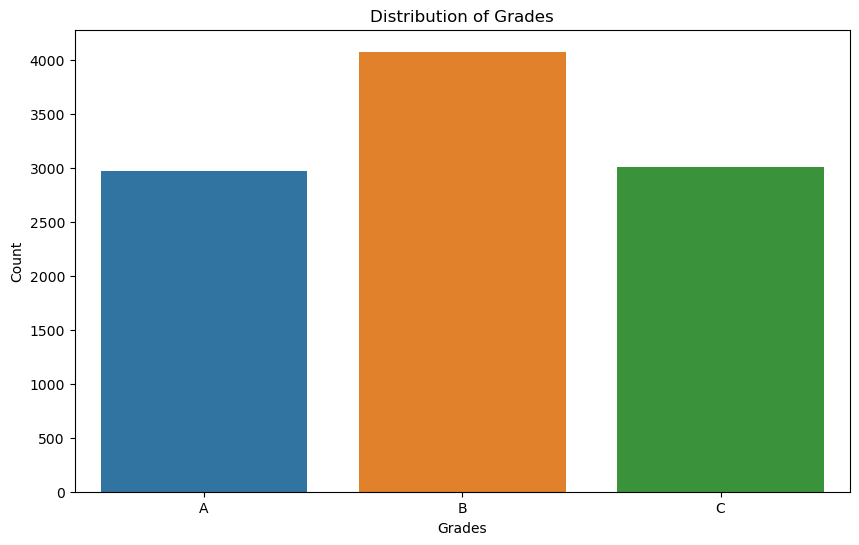

In [7]:
# Visualization 1: Distribution of Grades
grades_list = sorted(df['Grades'].unique())
plt.figure(figsize=(10, 6))
sns.countplot(x='Grades', data=df, order=grades_list)
plt.title('Distribution of Grades')
plt.xlabel('Grades')
plt.ylabel('Count')
plt.savefig("Distribution_of_Grades.png")
plt.show()

C:\Users\rjiang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\rjiang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\rjiang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


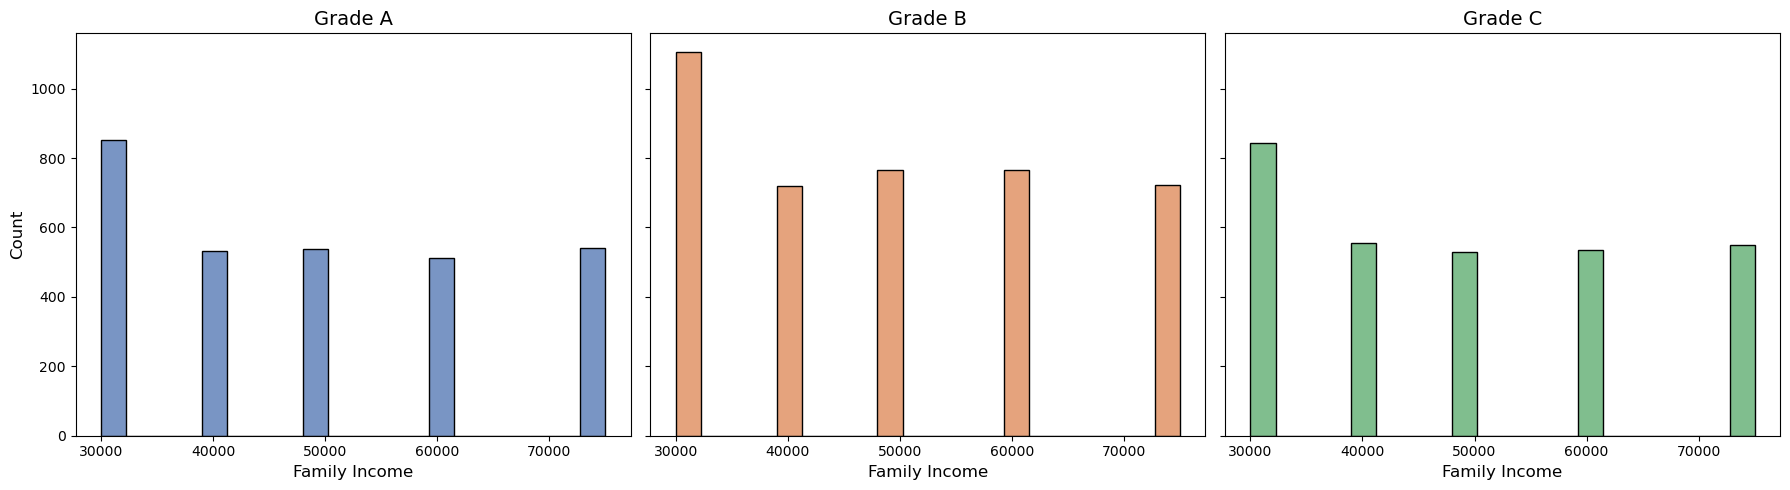

In [8]:
# Ensure 'Family_Income' is numeric, converting errors to NaN
df['Family_Income'] = pd.to_numeric(df['Family_Income'], errors='coerce')
df = df.dropna(subset=['Family_Income'])

# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a histogram for sorted Family_Income
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]
    sorted_income = subset['Family_Income'].sort_values()
    
    sns.histplot(sorted_income, bins=20, kde=False, ax=axes[i], color=sns.color_palette("deep")[i])
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Family Income', fontsize=12)
    if i == 0:
        axes[i].set_ylabel('Count', fontsize=12)
    else:
        axes[i].set_ylabel('')

# Adjust layout and display
plt.tight_layout()
plt.show()

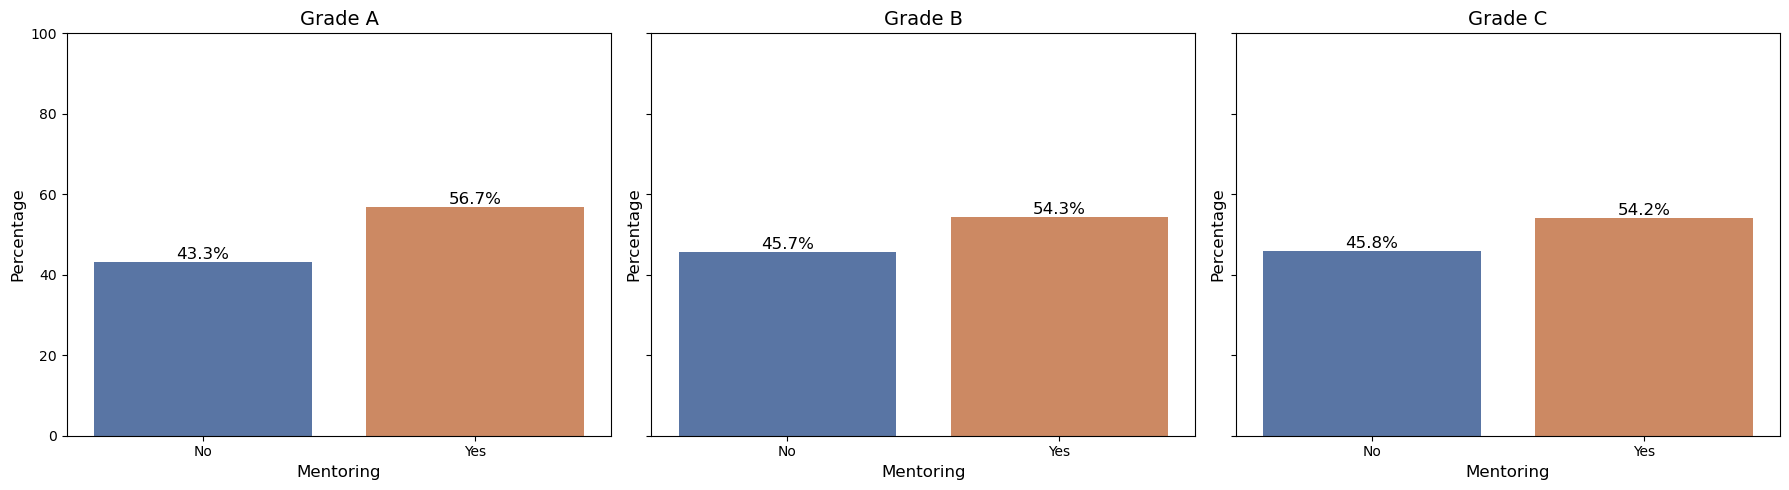

In [9]:
# Ensure the 'Mentoring' column exists and drop missing values
df = df.dropna(subset=['Grades', 'Mentoring'])

# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a percentage bar plot for Mentoring
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]

    # Calculate percentage distribution
    mentoring_counts = subset['Mentoring'].value_counts(normalize=True) * 100  # Convert to percentage
    mentoring_percent = mentoring_counts.reindex(['No', 'Yes'], fill_value=0)  # Ensure both categories are present

    # Create bar plot
    sns.barplot(x=mentoring_percent.index, y=mentoring_percent.values, ax=axes[i], palette="deep")
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Mentoring', fontsize=12)
    axes[i].set_ylabel('Percentage', fontsize=12)
    axes[i].set_ylim(0, 100)  # Set y-axis limit to 100%

    # Add percentage labels on bars
    for p, percentage in zip(axes[i].containers[0], mentoring_percent.values):
        axes[i].annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), 
                         ha='center', va='bottom', fontsize=12)

# Adjust layout and display
#plt.savefig("mentoring_by_grade.png")
plt.tight_layout()
plt.show()

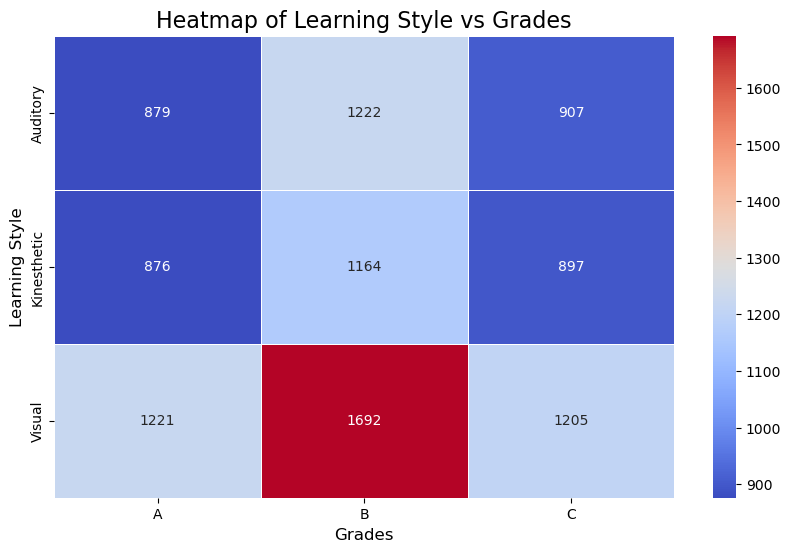

In [10]:
# Create a crosstab of Learning_Style vs Grades
cross_tab = pd.crosstab(df['Learning_Style'], df['Grades'])

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5)

# Add labels and title
plt.title('Heatmap of Learning Style vs Grades', fontsize=16)
plt.xlabel('Grades', fontsize=12)
plt.ylabel('Learning Style', fontsize=12)

# Show the plot
#plt.savefig("grades_learning_style_heatmap.png")
plt.show()

In [11]:
# Aggregate data to get percentage of "Yes" for each factor by grade
summary_df = df.groupby("Grades").agg({
    "Mentoring": lambda x: (x == "Yes").mean() * 100,
    "Tutoring": lambda x: (x == "Yes").mean() * 100,
    "Educational_Resources": lambda x: (x == "Yes").mean() * 100
}).reset_index()

# Melt the dataframe to long format
summary_df = summary_df.melt(id_vars="Grades", var_name="Factor", value_name="Percentage")

# Grade color mapping
grade_colors = {"A": "green", "B": "gold", "C": "red"}

# Create one set of traces per factor, with 3 bars (one per grade)
factors = summary_df["Factor"].unique()
traces = []
for factor in factors:
    df_factor = summary_df[summary_df["Factor"] == factor]
    trace = go.Bar(
        x=df_factor["Grades"],
        y=df_factor["Percentage"],
        marker_color=[grade_colors[grade] for grade in df_factor["Grades"]],
        text=df_factor["Percentage"].round(1),
        textposition="outside",
        name=factor,
        visible=(factor == factors[0])  
    )
    traces.append(trace)

# Radio buttons to toggle between factors
buttons = []
for i, factor in enumerate(factors):
    visibility = [j == i for j in range(len(factors))]
    buttons.append(dict(label=factor, method="update", args=[{"visible": visibility}]))

# Create and show figure
fig = go.Figure(data=traces)
fig.update_layout(
    title="Percentage of Student Participation in Academic Support Activities",
    xaxis_title="Grades",
    yaxis_title="Percentage of Students (%)",
    template="plotly_white",
    updatemenus=[dict(type="buttons", direction="right", buttons=buttons, x=0.5, xanchor="center", y=1.1)]
)

fig.write_html("interactive_bar_chart.html")


In [12]:
# Convert letter grades to numerical values (A=4, B=3, C=2)
grade_map = {'A': 4, 'B': 3, 'C': 2}
df['Numeric_Grade'] = df['Grades'].map(grade_map)

# Calculate average time wasted on social media by grade
avg_time_wasted = df.groupby('Grades')['Time_Wasted_on_Social_Media'].mean().reset_index()

bars = alt.Chart(avg_time_wasted).mark_bar(size=40).encode(
    x=alt.X('Grades:N', sort=['A', 'B', 'C'], title='Grade'),
    y=alt.Y('Time_Wasted_on_Social_Media:Q', title='Avg Time Wasted on Social Media (hrs)'),
    color=alt.Color('Grades:N', scale=alt.Scale(
        domain=['A', 'B', 'C'],
        range=['#4CAF50', '#FFC107', '#F44336']  # Green-Yellow-Red (A students likely waste less time)
    )),
    tooltip=['Grades', alt.Tooltip('Time_Wasted_on_Social_Media:Q', title='Avg Time Wasted', format='.2f')]
).properties(
    title='Average Time Wasted on Social Media by Grade',
    width=400,
    height=300
)

# Add text labels on bars
text = bars.mark_text(
    align='center',
    baseline='bottom',
    dy=-5  # Adjust position
).encode(
    text=alt.Text('Time_Wasted_on_Social_Media:Q', format='.2f')
)

(bars + text).configure_axis(
    labelFontSize=12,
    titleFontSize=14
).configure_title(
    fontSize=16
).save('avg_time_wasted_social_media.html')



In [13]:
# Convert grades
grade_map = {'A': 4, 'B': 3, 'C': 2}
df['Numeric_Grade'] = df['Grades'].map(grade_map)

# Sample data
df_sample = df.sample(n=5000, random_state=1)

# Create dropdown to filter by major
major_param = alt.param(
    name="MajorSelector",
    bind=alt.binding_select(options=sorted(df_sample['Major'].dropna().unique()), name='Select Major: '),
    value=sorted(df_sample['Major'].dropna().unique())[0]
)

# Apply the filter
filtered = alt.Chart(df_sample).transform_filter(major_param)

# Boxplot grouped by grade
boxplot = filtered.mark_boxplot(extent='min-max').encode(
    x=alt.X('Grades:N', sort=['A', 'B', 'C'], title='Grade'),
    y=alt.Y('Time_Wasted_on_Social_Media:Q', title='Time Wasted on Social Media (hrs)'),
    color=alt.Color('Grades:N', scale=alt.Scale(
        domain=['A', 'B', 'C'],
        range=['#4CAF50', '#FFC107', '#F44336']
    )),
    tooltip=[
        alt.Tooltip('Grades:N', title='Grade'),
        alt.Tooltip('Time_Wasted_on_Social_Media:Q', title='Time Wasted'),
        alt.Tooltip('Major:N')
    ]
).add_params(
    major_param
).properties(
    title='Time Wasted on Social Media by Grade (Filtered by Major)',
    width=300,
    height=300
)

# Save as HTML
boxplot.save('boxplot_time_wasted_by_grade.html')

# Also show in notebook 
boxplot


alt.Chart(...)

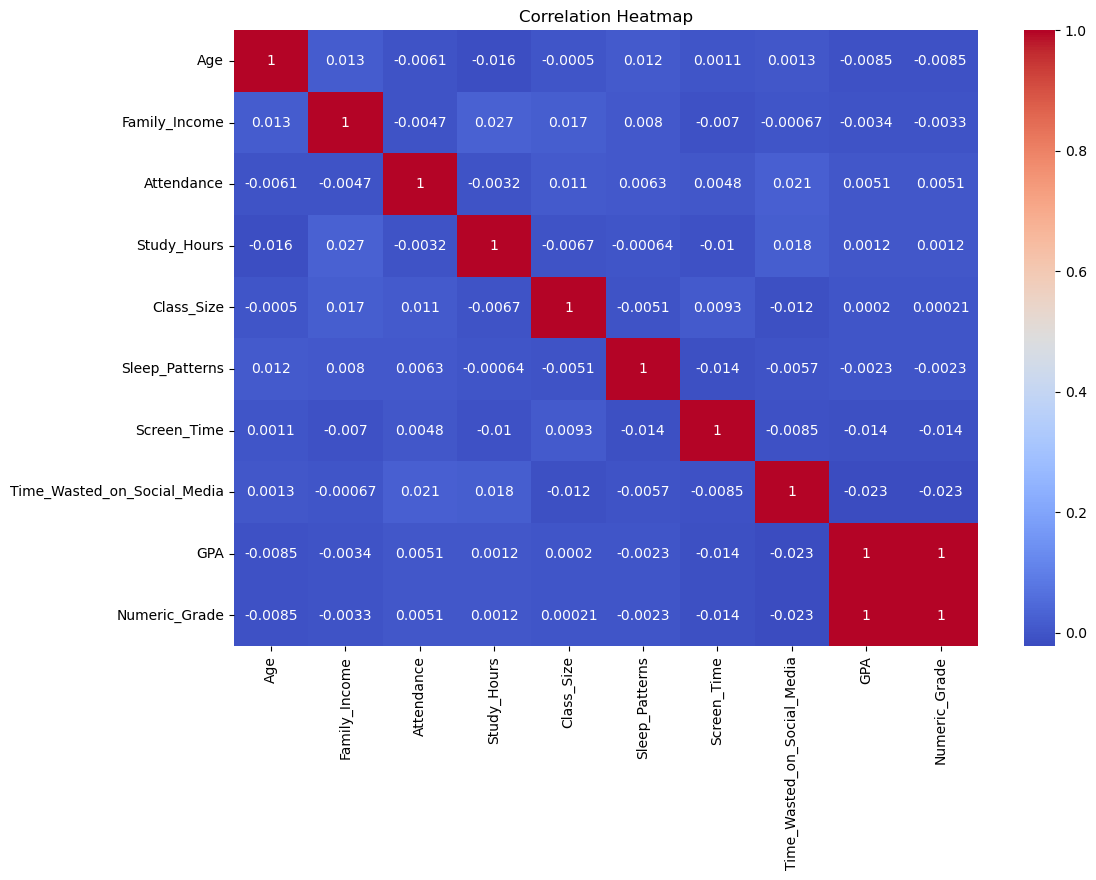

In [14]:
#  Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

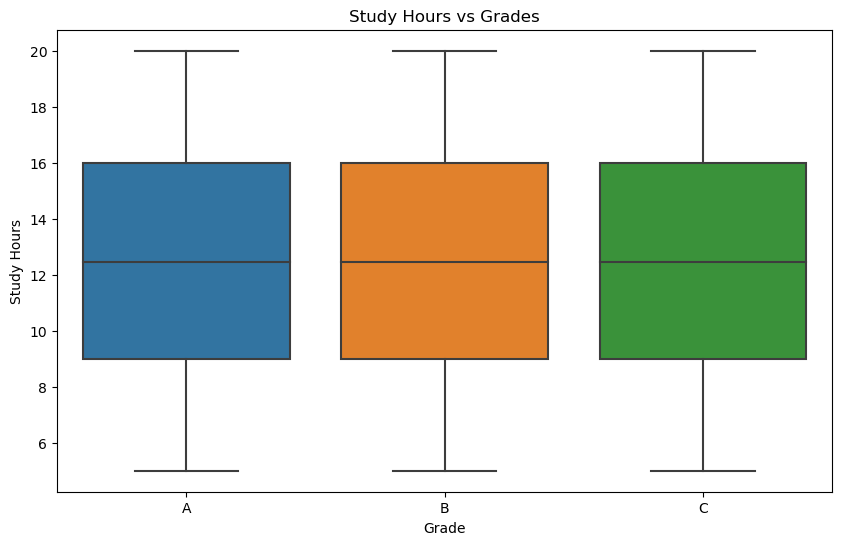

In [15]:
# Study Hours vs GPA
plt.figure(figsize=(10, 6))
sns.boxplot(x='Grades', y='Study_Hours', data=df, order=sorted(df['Grades'].unique()))
plt.title('Study Hours vs Grades')
plt.xlabel('Grade')
plt.ylabel('Study Hours')
plt.show()

In [16]:
fig = px.scatter(
    df,
    x='Study_Hours',
    y='GPA',
    color='Class_Participation',
    hover_data=['Major', 'Grades'],
    title='Study Hours vs GPA (Interactive by Major)'
)

# Save plot as HTML for iframe embedding
fig.write_html("plotly_chart.html")

C:\Users\rjiang\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [17]:
tree_data = df.groupby(['School_Type', 'Major', 'Grades']).size().reset_index(name='Count')

tree_data['Total_for_Major'] = tree_data.groupby(['School_Type', 'Major'])['Count'].transform('sum')

tree_data['Percentage'] = (tree_data['Count'] / tree_data['Total_for_Major'] * 100).round(2)

grade_colors = {
    'A': '#268100',
    'B': '#F8D70D',
    'C': '#F10015'
}

fig = px.treemap(
    tree_data,
    path=['School_Type', 'Major', 'Grades'],
    values='Count',
    title='Tree Diagram: School Type - Major - Grades',
    color='Grades',
    color_discrete_map=grade_colors,
    custom_data=['Count', 'Percentage']
)

# Update hover template so that it shows the Grade's count and its percentage.
fig.update_traces(
    hovertemplate=(
        '<b>%{label}</b><br>' +
        'Count: %{customdata[0]}<br>' +
        'Percentage: %{customdata[1]}%'
    )
)

# Optionally, update the cell text to include the percentage.
# Here, each leaf shows the Grade label along with the percentage.
fig.update_traces(texttemplate='%{label}<br>%{customdata[1]}%', selector=dict(type='treemap'))

# Save the figure to an HTML file
fig.write_html("tree_diagram.html")


In [18]:
# Clean and prepare the data with income ranges
df_cleaned = df[['School_Type', 'Major', 'Grades', 'Family_Income']].dropna()

# Convert Family_Income to numeric, then bin it into ranges
df_cleaned['Family_Income'] = pd.to_numeric(df_cleaned['Family_Income'], errors='coerce')
bins = [0, 30000, 60000, 90000, 120000, float('inf')]
labels_income = ['<30k', '30k-60k', '60k-90k', '90k-120k', '120k+']
df_cleaned['Income_Range'] = pd.cut(df_cleaned['Family_Income'], bins=bins, labels=labels_income)

# Get unique nodes and create index mapping
income_ranges = list(df_cleaned['Income_Range'].unique())
school_types = list(df_cleaned['School_Type'].unique())
majors = list(df_cleaned['Major'].unique())
grades = list(df_cleaned['Grades'].unique())

labels = income_ranges + school_types + majors + grades
label_indices = {label: i for i, label in enumerate(labels)}

# Create source, target, value lists for Income → School Type → Major → Grade
source = []
target = []
value = []

# Income -> School Type
for ir in income_ranges:
    for st in school_types:
        count = len(df_cleaned[(df_cleaned['Income_Range'] == ir) & (df_cleaned['School_Type'] == st)])
        if count > 0:
            source.append(label_indices[ir])
            target.append(label_indices[st])
            value.append(count)

# School Type -> Major
for st in school_types:
    for m in majors:
        count = len(df_cleaned[(df_cleaned['School_Type'] == st) & (df_cleaned['Major'] == m)])
        if count > 0:
            source.append(label_indices[st])
            target.append(label_indices[m])
            value.append(count)

# Major -> Grades
for m in majors:
    for g in grades:
        count = len(df_cleaned[(df_cleaned['Major'] == m) & (df_cleaned['Grades'] == g)])
        if count > 0:
            source.append(label_indices[m])
            target.append(label_indices[g])
            value.append(count)

# Store data for visualization
sankey_data = {
    "labels": labels,
    "source": source,
    "target": target,
    "value": value
}

In [19]:

ordered_labels = [
    '<30k', '30k-60k', '60k-90k', '90k-120k', '120k+',
] + sorted(df_cleaned['School_Type'].dropna().unique().tolist()) \
  + sorted(df_cleaned['Major'].dropna().unique().tolist()) \
  + ['A', 'B', 'C']  # Fixed grade order

income_colors = ['#aec6cf'] * 5
school_colors = ['#ffb347'] * len(df_cleaned['School_Type'].dropna().unique())
major_colors = ['#77dd77'] * len(df_cleaned['Major'].dropna().unique())
grade_colors = ['#cba0e3', '#b19cd9', '#8a2be2']
node_colors = income_colors + school_colors + major_colors + grade_colors


label_to_index = {label: i for i, label in enumerate(ordered_labels)}

source_fixed = []
target_fixed = []
value_fixed = []

for ir in ['<30k', '30k-60k', '60k-90k', '90k-120k', '120k+',]:
    for st in df_cleaned['School_Type'].unique():
        count = len(df_cleaned[(df_cleaned['Income_Range'] == ir) & (df_cleaned['School_Type'] == st)])
        if count > 0:
            source_fixed.append(label_to_index[ir])
            target_fixed.append(label_to_index[st])
            value_fixed.append(count)

for st in df_cleaned['School_Type'].unique():
    for m in df_cleaned['Major'].unique():
        count = len(df_cleaned[(df_cleaned['School_Type'] == st) & (df_cleaned['Major'] == m)])
        if count > 0:
            source_fixed.append(label_to_index[st])
            target_fixed.append(label_to_index[m])
            value_fixed.append(count)

for m in df_cleaned['Major'].unique():
    for g in ['A', 'B', 'C']:
        count = len(df_cleaned[(df_cleaned['Major'] == m) & (df_cleaned['Grades'] == g)])
        if count > 0:
            source_fixed.append(label_to_index[m])
            target_fixed.append(label_to_index[g])
            value_fixed.append(count)

link_color = ["rgba(150,150,150,0.4)"] * len(source_fixed)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=ordered_labels,
        color=node_colors 
    ),
    link=dict(
        source=source_fixed,
        target=target_fixed,
        value=value_fixed,
        color=link_color
    )
)])

fig.update_layout(title_text="Flow from Income Range → School Type → Major → Grade", font_size=10)

fig.write_html("sankey.html")



In [20]:
# Define the factors you want to toggle between
factors = list(df.columns)

# Create one figure for each factor
figures = []
for factor in factors:
    fig = px.box(df, x=factor, y='GPA', points='all',
                 title=f'GPA Distribution by {factor}',
                 labels={'GPA': 'GPA', factor: factor})
    figures.append(fig)

# Base figure: GPA by School_Type
fig = figures[0]

# Add dropdown to switch between factors
fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=[
                dict(label=factor,
                     method='update',
                     args=[
                         {'x': [df[factor]], 'y': [df['GPA']]},
                         {'title': f'GPA Distribution by {factor}',
                          'xaxis': {'title': factor}}
                     ])
                for factor in factors
            ],
            direction='down',
            showactive=True,
            x=0.0,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ]
)

fig.update_traces(boxpoints='all', jitter=0.3, pointpos=-1.8)
fig.update_layout(yaxis_title='GPA')

fig.write_html("fig6_box.html")
